# Car Market Trends Analysis

## 1. Project Introduction

The automobile market generates a large amount of data related to car prices, fuel types, transmission types, ownership, seller types, manufacturing years, and kilometers driven. Analyzing this data can help identify important patterns and trends in the car market.

This project focuses on analyzing car market data using Python and data analytics techniques. The dataset is explored to understand the characteristics of different cars and identify the factors associated with their selling prices.

Pandas is used for data loading, cleaning, manipulation, and analysis. NumPy is used for numerical calculations such as mean, median, minimum, and maximum values. Matplotlib is used to create different visualizations, including bar charts, pie charts, line charts, scatter plots, histograms, box plots, and correlation heatmaps.

The project analyzes different factors such as fuel type, seller type, transmission type, ownership, car models, present price, selling price, car age, and kilometers driven.

The main objective of this project is to transform raw car market data into meaningful insights and understand the patterns, trends, and relationships that may influence car prices in the used-car market.

###2. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###3. Load Dataset

####The Car Dekho dataset is loaded into a Pandas DataFrame for further analysis.

In [ ]:
!pip install -q gdown

import gdown
import pandas as pd

file_id = "14_8a0VcjFyBoVIgXIw_GUFSGmwEYYDNC"

url = f"https://drive.google.com/uc?id={file_id}"

output = "/content/car_data.csv"

gdown.download(url, output, quiet=False)

df = pd.read_csv(output)

df.head()

Downloading...
From: https://drive.google.com/uc?id=14_8a0VcjFyBoVIgXIw_GUFSGmwEYYDNC
To: /content/car_data.csv
100%|██████████| 17.2k/17.2k [00:00<00:00, 13.6MB/s]


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


###4. Dataset Overview

####4.1 View Dataset

In [2]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


####4.2 Dataset Shape

In [ ]:
df.shape

(301, 9)

####4.3 Column Names

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

####4.4 Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


####4.5 Statistical Summary

In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


###5. Data Cleaning

####5.1 Missing Values

In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


####5.2 Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(2)

####5.3 Data Types

In [ ]:
df.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


###6. Feature Engineering

####6.1 Create Car Age

In [ ]:
df["Car_Age"] = 2026 - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


## 7. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the main characteristics, patterns, and distributions present in the car market dataset.

### 7.1 Fuel Type Analysis

In this section, we analyze the distribution of cars based on their fuel type.

In [ ]:
df["Fuel_Type"].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [ ]:
fuel_counts=df["Fuel_Type"].value_counts()
print("Number of Cars by Fuel Type")
print(fuel_counts)

Number of Cars by Fuel Type
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


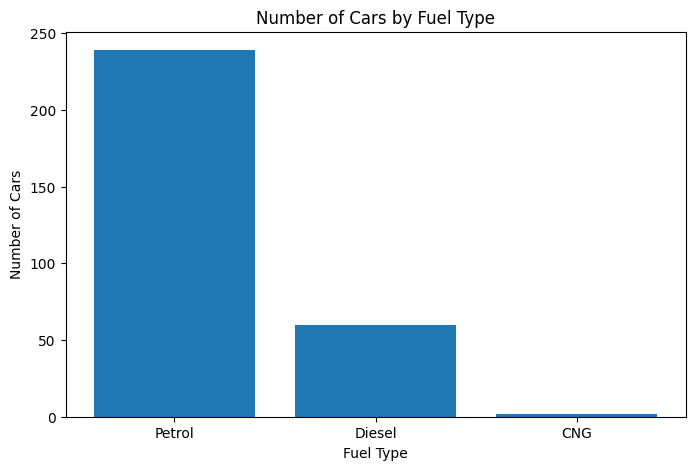

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(fuel_counts.index, fuel_counts.values)

plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

### Observation

The above analysis shows the distribution of cars according to their fuel type. The fuel type with the highest number of cars represents the most common fuel category in the dataset.

### 7.2 Seller Type Analysis

In this section, we analyze the distribution of cars based on the type of seller.

In [ ]:
df["Seller_Type"].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


In [ ]:
seller_counts = df["Seller_Type"].value_counts()

print("Number of cars by seller type:")
print(seller_counts)

Number of cars by seller type:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64


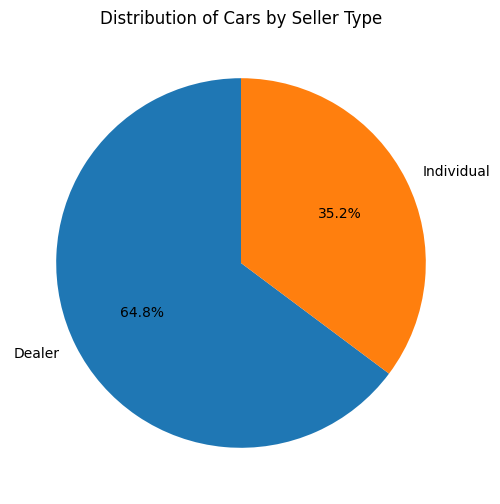

In [ ]:
plt.figure(figsize=(8, 6))

plt.pie(
    seller_counts.values,
    labels=seller_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Cars by Seller Type")

plt.show()
plt.show()

### Observation

The pie chart shows the proportion of cars available from each seller type. The largest segment represents the seller category with the highest number of cars in the dataset.

### 7.3 Transmission Analysis

In this section, we analyze the distribution of cars based on their transmission type and identify the most common transmission category in the dataset.

In [ ]:
transmission_counts = df["Transmission"].value_counts()

print("Number of cars by transmission type:")
print(transmission_counts)

Number of cars by transmission type:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


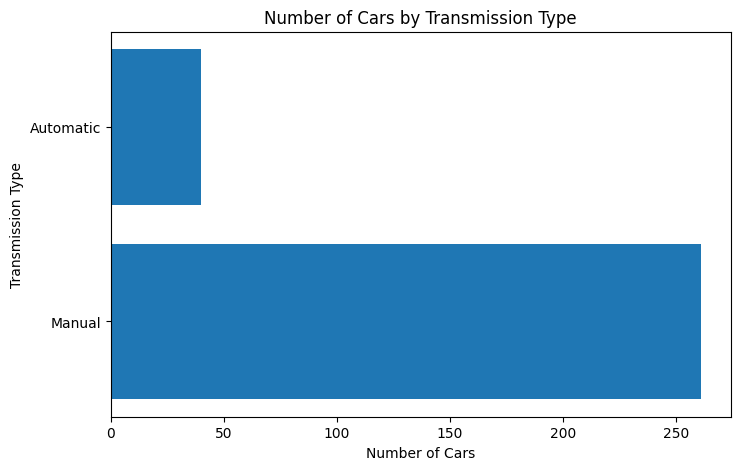

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    transmission_counts.index,
    transmission_counts.values
)

plt.title("Number of Cars by Transmission Type")
plt.xlabel("Number of Cars")
plt.ylabel("Transmission Type")

plt.show()

### Observation

The horizontal bar chart shows the distribution of cars according to transmission type. The transmission category with the longest bar represents the most common transmission type in the dataset.

### 7.4 Ownership Analysis

In this section, we analyze the distribution of cars based on the number of previous owners and examine how ownership varies across the dataset.

In [ ]:
owner_counts = df["Owner"].value_counts().sort_index()

print("Number of cars by previous owners:")
print(owner_counts)

Number of cars by previous owners:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


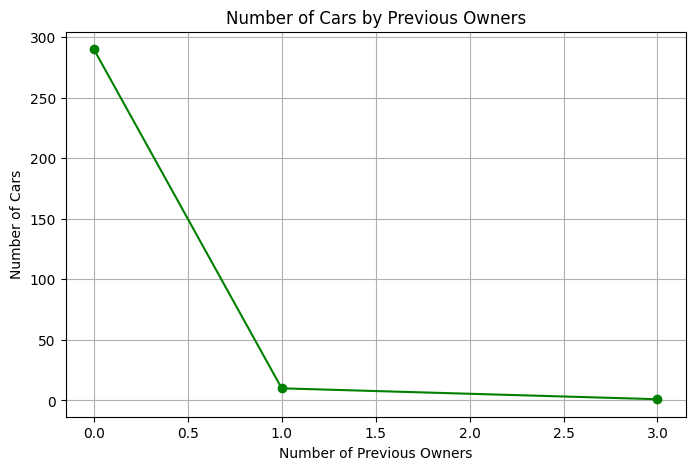

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    owner_counts.index,
    owner_counts.values,
    marker="o",
    color="Green"
)

plt.title("Number of Cars by Previous Owners")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Number of Cars")

plt.grid(True)

plt.show()

### Observation

The line chart shows how the number of cars varies according to the number of previous owners. It helps identify which ownership category contains the highest number of cars in the dataset.

### 7.5 Car Model Analysis

In this section, we analyze the car models available in the dataset and identify the most frequently occurring car models.

In [ ]:
car_counts = df["Car_Name"].value_counts()

print("Top 10 most common car models:")
print(car_counts.head(10))

Top 10 most common car models:
Car_Name
city                         26
corolla altis                16
verna                        14
fortuner                     11
brio                         10
ciaz                          9
i20                           9
innova                        9
grand i10                     8
Royal Enfield Classic 350     7
Name: count, dtype: int64


In [ ]:
top_cars = car_counts.head(10)

top_cars

,count
Car_Name,
city,26
corolla altis,16
verna,14
fortuner,11
brio,10
ciaz,9
i20,9
innova,9
grand i10,8


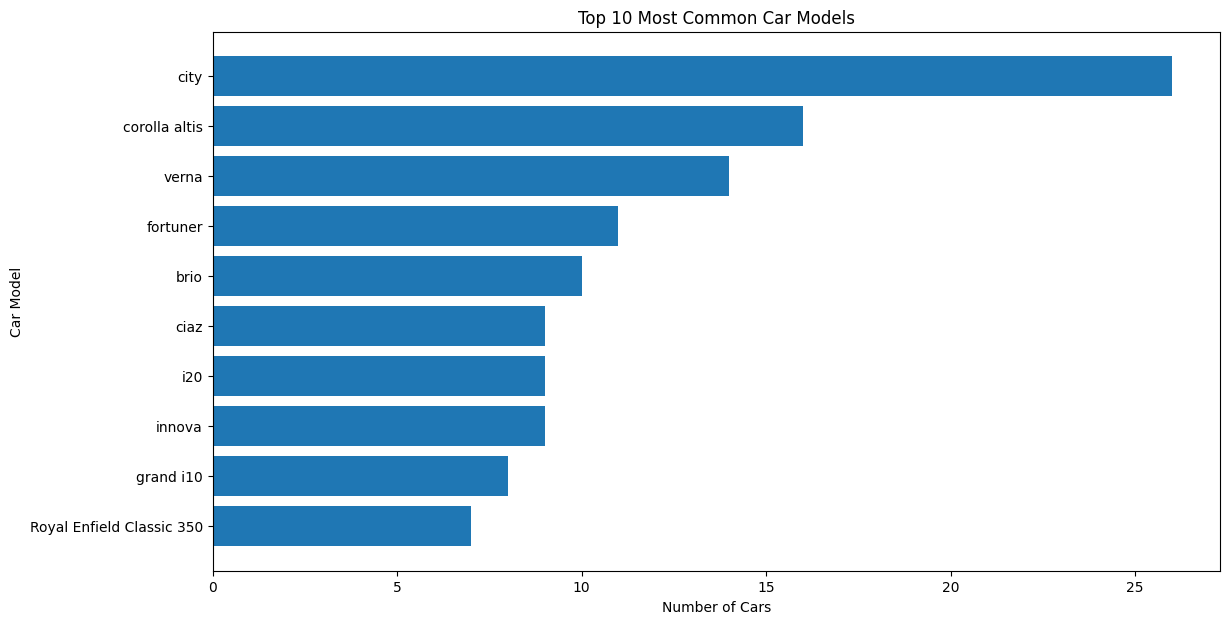

In [ ]:
plt.figure(figsize=(13, 7))

plt.barh(
    top_cars.index,
    top_cars.values
)

plt.title("Top 10 Most Common Car Models")
plt.xlabel("Number of Cars")
plt.ylabel("Car Model")

plt.gca().invert_yaxis()

plt.show()

### Observation

The horizontal bar chart shows the top 10 most frequently occurring car models in the dataset. The model with the longest bar is the most commonly represented car model in the dataset.


## 8. Numerical Analysis

In this section, numerical methods are used to analyze important numerical variables in the car market dataset. Measures such as mean, median, minimum, maximum, and correlation are calculated to understand car prices, present prices, kilometers driven, car age, and ownership.

### 8.1 Mean

The mean represents the average value of a numerical variable. In this analysis, we calculate the average selling price, present price, kilometers driven, and car age.

In [ ]:
mean_values = {
    "Average Selling Price": np.mean(df["Selling_Price"]),
    "Average Present Price": np.mean(df["Present_Price"]),
    "Average Kms Driven": np.mean(df["Kms_Driven"]),
    "Average Car Age": np.mean(df["Car_Age"])
}

for metric, value in mean_values.items():
    print(metric, ":", value)

Average Selling Price : 4.661295681063123
Average Present Price : 7.628471760797343
Average Kms Driven : 36947.20598006644
Average Car Age : 12.372093023255815


### Observation

The calculated mean values provide an overview of the average selling price, present price, kilometers driven, and age of the cars in the dataset.

### 8.2 Median

The median represents the middle value of a dataset when the values are arranged in ascending or descending order. It is useful for understanding the typical value while reducing the effect of extremely high or low values.

In [ ]:
median_values = {
    "Median Selling Price": np.median(df["Selling_Price"]),
    "Median Present Price": np.median(df["Present_Price"]),
    "Median Kms Driven": np.median(df["Kms_Driven"]),
    "Median Car Age": np.median(df["Car_Age"])
}

for metric, value in median_values.items():
    print(metric, ":", value)

Median Selling Price : 3.6
Median Present Price : 6.4
Median Kms Driven : 32000.0
Median Car Age : 12.0


### Observation

The median values provide the middle point of the selected numerical variables. Comparing the mean and median can help identify whether the data contains extreme values or is unevenly distributed.

###Comparision Between Mean and Median

In [ ]:
comparison = pd.DataFrame({
    "Metric": [
        "Selling Price",
        "Present Price",
        "Kms Driven",
        "Car Age"
    ],
    "Mean": [
        np.mean(df["Selling_Price"]),
        np.mean(df["Present_Price"]),
        np.mean(df["Kms_Driven"]),
        np.mean(df["Car_Age"])
    ],
    "Median": [
        np.median(df["Selling_Price"]),
        np.median(df["Present_Price"]),
        np.median(df["Kms_Driven"]),
        np.median(df["Car_Age"])
    ]
})

comparison

,Metric,Mean,Median
0,Selling Price,4.661296,3.6
1,Present Price,7.628472,6.4
2,Kms Driven,36947.205980,32000.0
3,Car Age,12.372093,12.0


### 8.3 Minimum

The minimum value represents the lowest value recorded for a numerical variable in the dataset. In this analysis, we identify the minimum selling price, present price, kilometers driven, and car age.

In [ ]:
minimum_values = {
    "Minimum Selling Price": np.min(df["Selling_Price"]),
    "Minimum Present Price": np.min(df["Present_Price"]),
    "Minimum Kms Driven": np.min(df["Kms_Driven"]),
    "Minimum Car Age": np.min(df["Car_Age"])
}

for metric, value in minimum_values.items():
    print(metric, ":", value)

Minimum Selling Price : 0.1
Minimum Present Price : 0.32
Minimum Kms Driven : 500
Minimum Car Age : 8


### Observation

The minimum values show the lowest recorded selling price, present price, kilometers driven, and car age among the cars in the dataset.

### 8.4 Maximum

The maximum value represents the highest value recorded for a numerical variable in the dataset. In this analysis, we identify the maximum selling price, present price, kilometers driven, and car age.

In [ ]:
maximum_table = pd.DataFrame({
    "Metric": [
        "Selling Price",
        "Present Price",
        "Kms Driven",
        "Car Age"
    ],
    "Maximum Value": [
        np.max(df["Selling_Price"]),
        np.max(df["Present_Price"]),
        np.max(df["Kms_Driven"]),
        np.max(df["Car_Age"])
    ]
})

maximum_table

,Metric,Maximum Value
0,Selling Price,35.0
1,Present Price,92.6
2,Kms Driven,500000.0
3,Car Age,23.0


### Observation

The maximum values show the highest recorded selling price, present price, kilometers driven, and car age among the cars in the dataset.

### 8.5 Coorelation

Coorelation measures the Strength and Direction of the relationship between two Numerical Values.In this Analysis, we examine the coorelation between important Factors such as selling price, present price, kilometers driven, car age, and ownership

In [ ]:
coorelation_table=df[
    [
     "Selling_Price",
     "Present_Price",
     "Kms_Driven",
     "Car_Age",
     "Owner"
    ]
].corr()
coorelation_table


,Selling_Price,Present_Price,Kms_Driven,Car_Age,Owner
Selling_Price,1.000000,0.878983,0.029187,-0.236141,-0.088344
Present_Price,0.878983,1.000000,0.203647,0.047584,0.008057
Kms_Driven,0.029187,0.203647,1.000000,0.524342,0.089216
Car_Age,-0.236141,0.047584,0.524342,1.000000,0.182104
Owner,-0.088344,0.008057,0.089216,0.182104,1.000000


In [ ]:
Selling_Price_correlation=(
    coorelation_table["Selling_Price"]
    .drop("Selling_Price")
    .sort_values(ascending=False)
)
Selling_Price_correlation

,Selling_Price
Present_Price,0.878983
Kms_Driven,0.029187
Owner,-0.088344
Car_Age,-0.236141


###Observation

The Coorelation Analysis shows the Strength and Direction of the relationship between price and other numerical variables. A positive coorelation indicates that both variables tend to increase together, while a negative coorelation indicates that one variable tends to decrease as the other Factors have a stronger relationship with Car Selling Price.

## 9. Market Analysis

In this section, we analyze different characteristics of the car market to understand the distribution and pricing patterns across fuel type, transmission, seller type, ownership, and car models.

### 9.1 Fuel Type

In this section, we compare the average selling price of cars across different fuel types to understand how fuel type relates to the used-car market.

In [ ]:
fuel_market = df.groupby("Fuel_Type")["Selling_Price"].mean().sort_values(ascending=False)

fuel_market

,Selling_Price
Fuel_Type,
Diesel,10.278500
Petrol,3.264184
CNG,3.100000


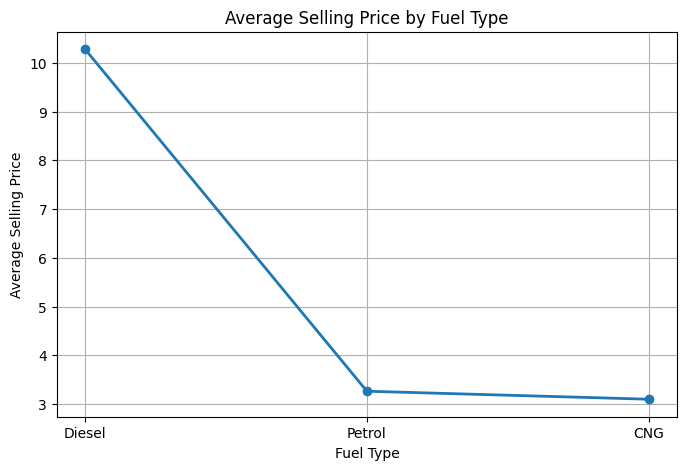

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    fuel_market.index,
    fuel_market.values,
    marker="o",
    linewidth=2
)

plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")

plt.grid(True)

plt.show()

### Observation

The analysis compares the average selling price across different fuel types. The fuel type with the highest average selling price represents the category with the highest average resale value in the dataset.

### 9.2 Transmission

In this section, we compare the average selling price of cars across different transmission types to understand how transmission type relates to resale value.

In [ ]:
transmission_market = (
    df.groupby("Transmission")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

transmission_market

,Selling_Price
Transmission,
Automatic,9.420000
Manual,3.931992


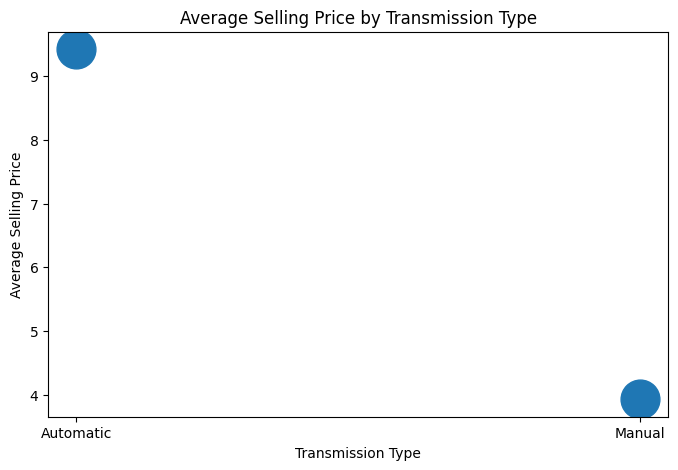

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    transmission_market.index,
    transmission_market.values,
    s=780
)

plt.title("Average Selling Price by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Average Selling Price")

plt.show()

### Observation

The analysis compares the average selling price of cars across different transmission types. The transmission type with the highest average selling price represents the category with the highest average resale value in the dataset.

### 9.3 Seller Type

In this section, we compare the average selling price of cars across different seller types to understand how seller type relates to resale value.

In [ ]:
seller_market = (
    df.groupby("Seller_Type")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

seller_market

,Selling_Price
Seller_Type,
Dealer,6.721692
Individual,0.870943


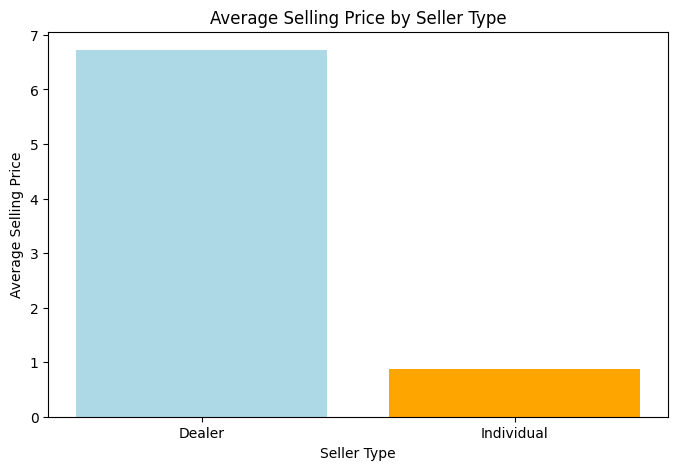

In [ ]:
plt.figure(figsize=(8, 5))

colors = ["lightblue", "orange", "green"]

plt.bar(
    seller_market.index,
    seller_market.values,
    color=colors[:len(seller_market)]
)

plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price")

plt.show()

### Observation

The analysis compares the average selling price across different seller types. The seller type with the highest average selling price represents the category with the highest average resale value in the dataset.

### 9.4 Ownership

In this section, we compare the average selling price of cars based on the number of previous owners to understand how ownership history relates to resale value.

In [ ]:
owner_market = (
    df.groupby("Owner")["Selling_Price"]
    .mean()
    .sort_index()
)

owner_market

,Selling_Price
Owner,
0,4.761552
1,1.970000
3,2.500000


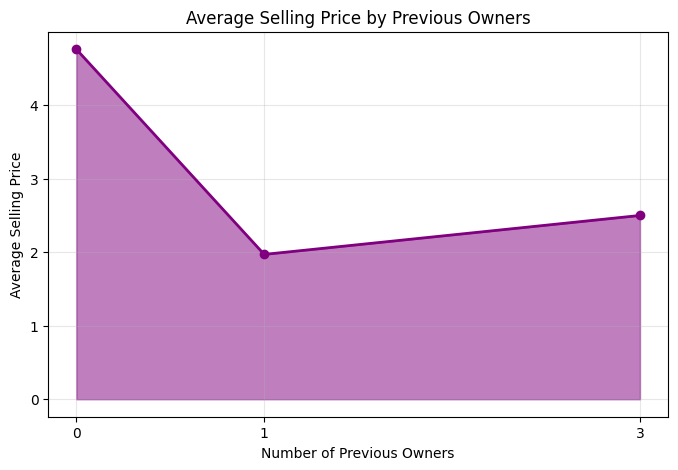

In [ ]:
plt.figure(figsize=(8, 5))

plt.fill_between(
    owner_market.index,
    owner_market.values,
    alpha=0.5,
    color="purple"
)

plt.plot(
    owner_market.index,
    owner_market.values,
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title("Average Selling Price by Previous Owners")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Average Selling Price")

plt.xticks(owner_market.index)

plt.grid(True, alpha=0.3)

plt.show()

### Observation

The area chart shows how the average selling price changes with the number of previous owners. It helps identify whether cars with fewer or more previous owners tend to have higher average resale values in the dataset.

### 9.5 Car Models

In this section, we analyze the average selling price of different car models and identify the top 10 car models with the highest average selling price.

In [ ]:
car_model_market = (
    df.groupby("Car_Name")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

car_model_market.head(10)

,Selling_Price
Car_Name,
land cruiser,35.000000
fortuner,18.685455
innova,12.777778
creta,11.800000
elantra,11.600000
vitara brezza,9.250000
ciaz,7.472222
city,7.419231
corolla altis,7.183125


In [ ]:
top_10_models = car_model_market.head(10)

top_10_models

,Selling_Price
Car_Name,
land cruiser,35.000000
fortuner,18.685455
innova,12.777778
creta,11.800000
elantra,11.600000
vitara brezza,9.250000
ciaz,7.472222
city,7.419231
corolla altis,7.183125


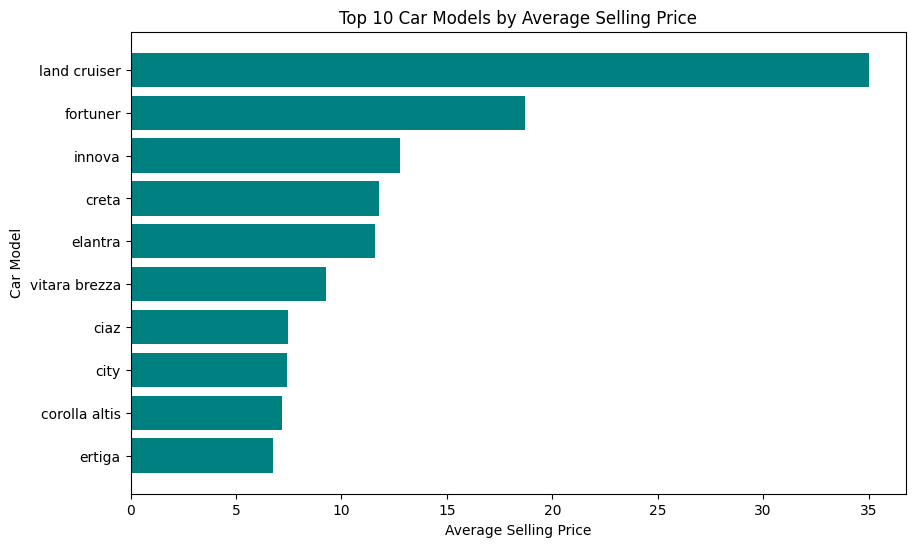

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_models.index,
    top_10_models.values,
    color="teal"
)

plt.title("Top 10 Car Models by Average Selling Price")
plt.xlabel("Average Selling Price")
plt.ylabel("Car Model")

plt.gca().invert_yaxis()

plt.show()

### Observation

The chart shows the top 10 car models based on their average selling price. The model with the longest bar represents the car model with the highest average selling price among the selected models.

## 10. Price Analysis

In this section, we analyze the factors related to car prices and examine how present price, selling price, car age, and kilometers driven are associated with the used-car market.

### 10.1 Present Price

In this section, we analyze the present price of cars to understand the price distribution in the used-car market.

In [ ]:
present_price_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Minimum",
        "Maximum"
    ],
    "Present Price": [
        np.mean(df["Present_Price"]),
        np.median(df["Present_Price"]),
        np.min(df["Present_Price"]),
        np.max(df["Present_Price"])
    ]
})

present_price_stats

,Metric,Present Price
0,Mean,7.628472
1,Median,6.400000
2,Minimum,0.320000
3,Maximum,92.600000


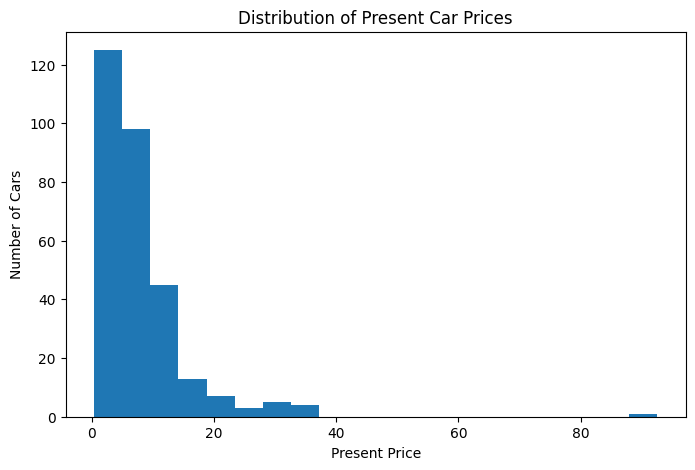

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Present_Price"],
    bins=20
)

plt.title("Distribution of Present Car Prices")
plt.xlabel("Present Price")
plt.ylabel("Number of Cars")

plt.show()

### Observation

The histogram shows the distribution of present car prices in the dataset. It helps identify the price range in which most cars are concentrated and shows the overall spread of present prices.

### 10.2 Selling Price

In this section, we analyze the selling price of cars to understand the price distribution and identify the range in which most cars are sold.

In [ ]:
selling_price_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Minimum",
        "Maximum"
    ],
    "Selling Price": [
        np.mean(df["Selling_Price"]),
        np.median(df["Selling_Price"]),
        np.min(df["Selling_Price"]),
        np.max(df["Selling_Price"])
    ]
})

selling_price_stats

,Metric,Selling Price
0,Mean,4.661296
1,Median,3.600000
2,Minimum,0.100000
3,Maximum,35.000000


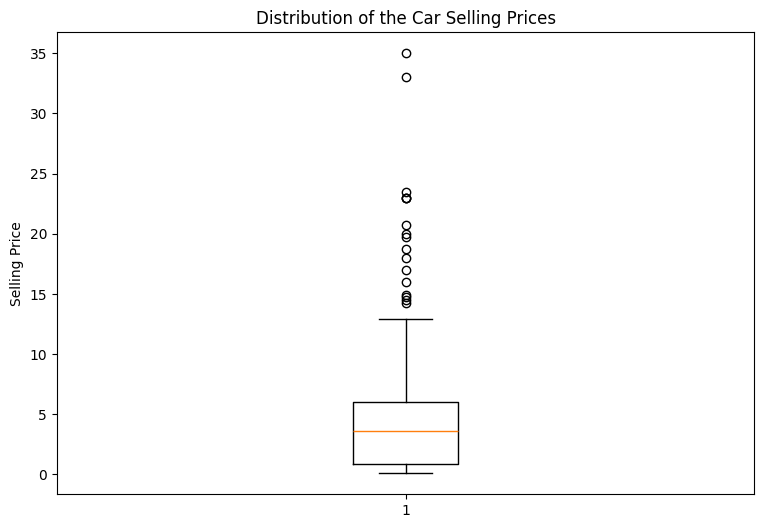

In [ ]:
plt.figure(figsize=(9,6))
plt.boxplot(df["Selling_Price"])
plt.title("Distribution of the Car Selling Prices")
plt.ylabel("Selling Price")
plt.show()

### Observation

The box plot shows the distribution of selling prices and helps identify the central range of prices, spread of the data, and any potential outliers in the selling price.

### 10.3 Car Age

In this section, we analyze the age of cars and examine its relationship with selling price to understand how car age may affect resale value.

In [ ]:
car_age_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Minimum",
        "Maximum"
    ],
    "Car Age": [
        np.mean(df["Car_Age"]),
        np.median(df["Car_Age"]),
        np.min(df["Car_Age"]),
        np.max(df["Car_Age"])
    ]
})

car_age_stats

,Metric,Car Age
0,Mean,12.372093
1,Median,12.000000
2,Minimum,8.000000
3,Maximum,23.000000


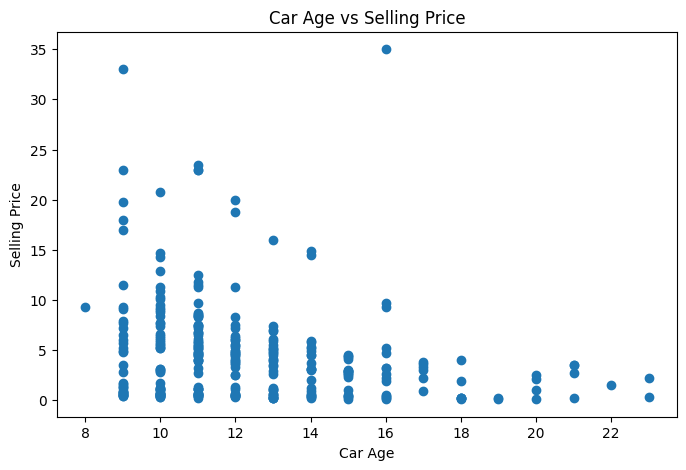

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Car_Age"],
    df["Selling_Price"]
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

### Observation

The scatter plot shows the relationship between car age and selling price. It helps us understand whether selling prices tend to change as the age of the car increases.

### 10.4 Kms Driven

In this section, we analyze the kilometers driven by cars and examine its relationship with selling price to understand how mileage may affect resale value.

In [ ]:
kms_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Minimum",
        "Maximum"
    ],
    "Kms Driven": [
        np.mean(df["Kms_Driven"]),
        np.median(df["Kms_Driven"]),
        np.min(df["Kms_Driven"]),
        np.max(df["Kms_Driven"])
    ]
})

kms_stats

,Metric,Kms Driven
0,Mean,36947.20598
1,Median,32000.00000
2,Minimum,500.00000
3,Maximum,500000.00000


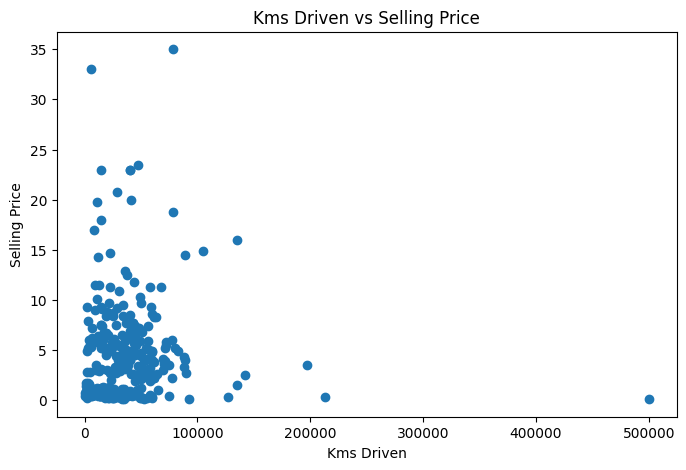

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Kms_Driven"],
    df["Selling_Price"]
)

plt.title("Kms Driven vs Selling Price")
plt.xlabel("Kms Driven")
plt.ylabel("Selling Price")

plt.show()

### Observation

The scatter plot shows the relationship between kilometers driven and selling price. It helps us understand whether cars with higher mileage tend to have different selling prices compared with cars with lower mileage.

## 11. Data Visualization

Data visualization is used to represent the car market data graphically. Different types of charts are used to identify patterns, comparisons, trends, distributions, and relationships within the dataset.

### 11.1 Bar Charts

Bar charts are used to compare values across different categories. In this section, we visualize the average selling price of cars by fuel type.

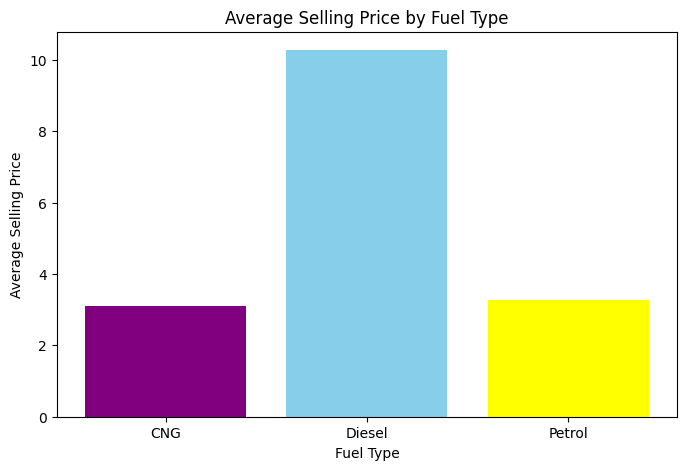

In [ ]:
fuel_price = df.groupby("Fuel_Type")["Selling_Price"].mean()

plt.figure(figsize=(8, 5))
color=["Purple","SkyBlue","Yellow"]

plt.bar(
    fuel_price.index,
    fuel_price.values,
    color=color
)

plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")

plt.show()

### Observation

The bar chart compares the average selling price of cars across different fuel types. It helps identify which fuel type has the highest and lowest average selling price in the dataset.

### 11.2 Line Charts

Line charts are used to show trends and changes over an ordered variable. In this section, we visualize the average selling price of cars across different manufacturing years.

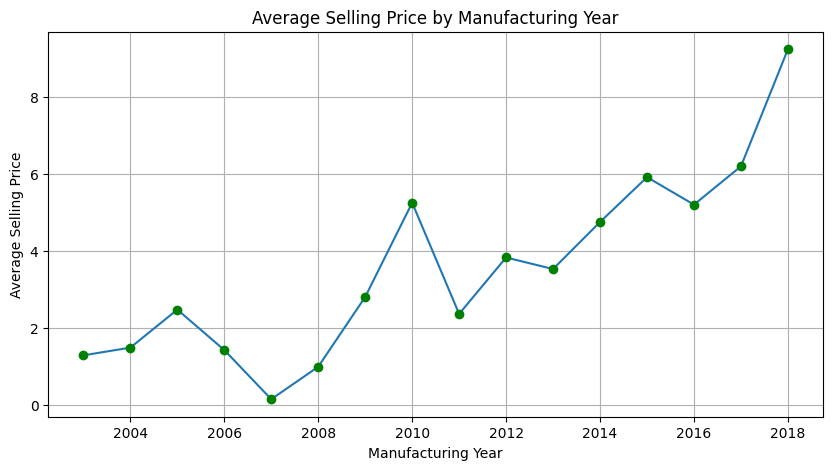

In [ ]:
year_price = df.groupby("Year")["Selling_Price"].mean().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
    year_price.index,
    year_price.values,
    marker="o",
    markerfacecolor="green",
    markeredgecolor="green"
)

plt.title("Average Selling Price by Manufacturing Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Average Selling Price")

plt.grid(True)

plt.show()

### Observation

The line chart shows how the average selling price changes across different manufacturing years. It helps identify the overall price trend of cars based on their manufacturing year.

### 11.3 Scatter Plots

Scatter plots are used to examine the relationship between two numerical variables. In this section, we visualize the relationship between present price and selling price.

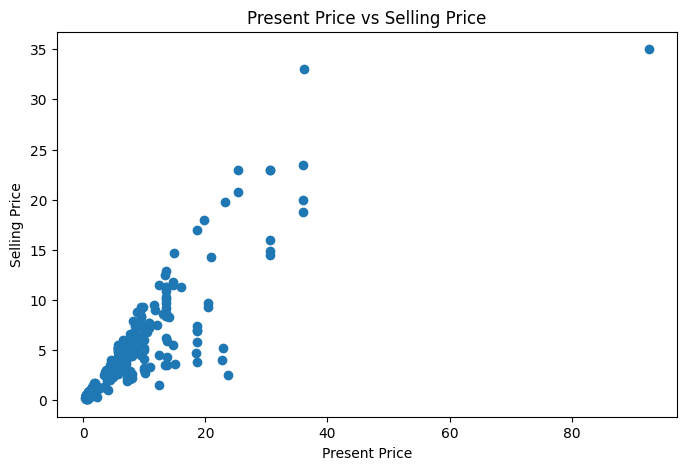

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Present_Price"],
    df["Selling_Price"]
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

### Observation

The scatter plot shows the relationship between present price and selling price. The distribution of points helps identify whether cars with higher present prices generally have higher selling prices and whether there are any unusual observations.

### 11.4 Histogram

Histograms are used to show the distribution of numerical data. In this section, we visualize the distribution of kilometers driven by the cars in the dataset.

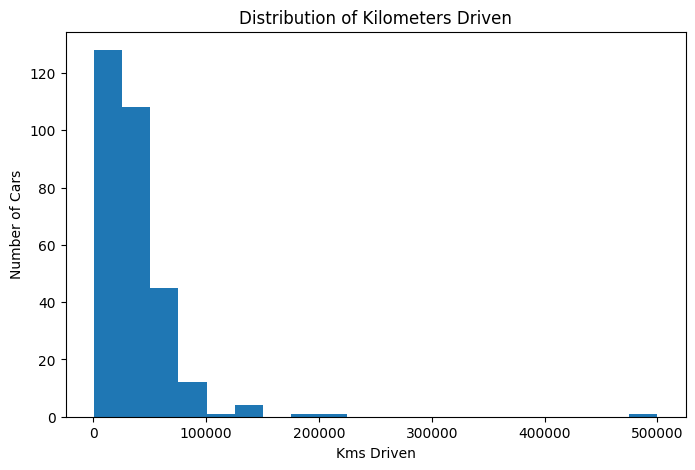

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Kms_Driven"],
    bins=20
)

plt.title("Distribution of Kilometers Driven")
plt.xlabel("Kms Driven")
plt.ylabel("Number of Cars")

plt.show()

### Observation

The histogram shows the distribution of kilometers driven by the cars. It helps identify the range of mileage in which most cars are concentrated and shows how the kilometers driven are distributed across the dataset.

### 11.5 Box Plot

Box plots are used to understand the distribution and spread of numerical data. In this section, we visualize the present price of cars to identify the median, variation, and potential outliers.

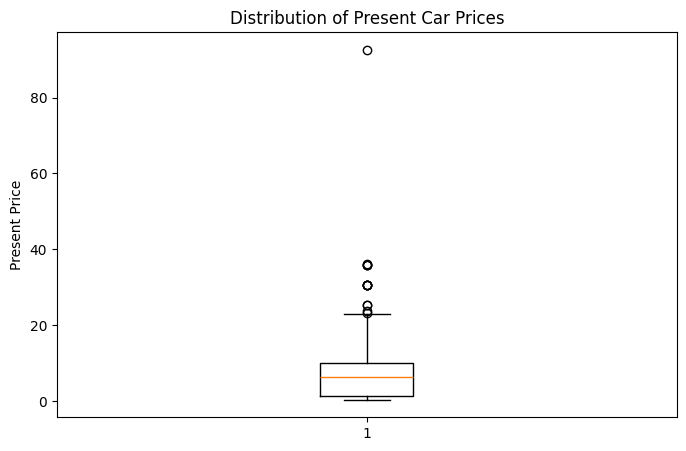

In [8]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    df["Present_Price"]
)

plt.title("Distribution of Present Car Prices")
plt.ylabel("Present Price")

plt.show()

### Observation

The box plot shows the distribution of present car prices. It helps identify the median price, spread of the data, and potential outliers with unusually high or low present prices.

## 12. Correlation Analysis

Correlation analysis is used to measure the relationship between numerical variables in the dataset. It helps identify which factors have positive or negative relationships with car selling price.

### 12.1 Correlation Matrix

In this section, we calculate the correlation between important numerical variables such as selling price, present price, kilometers driven, car age, and ownership.

In [ ]:
numerical_columns = [
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Car_Age",
    "Owner"
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Selling_Price,Present_Price,Kms_Driven,Car_Age,Owner
Selling_Price,1.000000,0.878983,0.029187,-0.236141,-0.088344
Present_Price,0.878983,1.000000,0.203647,0.047584,0.008057
Kms_Driven,0.029187,0.203647,1.000000,0.524342,0.089216
Car_Age,-0.236141,0.047584,0.524342,1.000000,0.182104
Owner,-0.088344,0.008057,0.089216,0.182104,1.000000


### Observation

The correlation matrix shows the strength and direction of relationships between the selected numerical variables. Values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak or no linear relationship between the variables.

In this section, we Examine how strongly each numerical variable is related to the selling price of Cars

In [ ]:
selling_price_correlation=(
    correlation_matrix["Selling_Price"]
    .sort_values(ascending=False)
)
selling_price_correlation

,Selling_Price
Selling_Price,1.000000
Present_Price,0.878983
Kms_Driven,0.029187
Owner,-0.088344
Car_Age,-0.236141


### Observation

The correlation values show how strongly the numerical variables are related to selling price. Positive values indicate a positive relationship, while negative values indicate an inverse relationship.

### 12.3 Correlation Heatmap

A correlation heatmap provides a visual representation of the relationships between numerical variables. Different colors represent the strength and direction of the correlation.

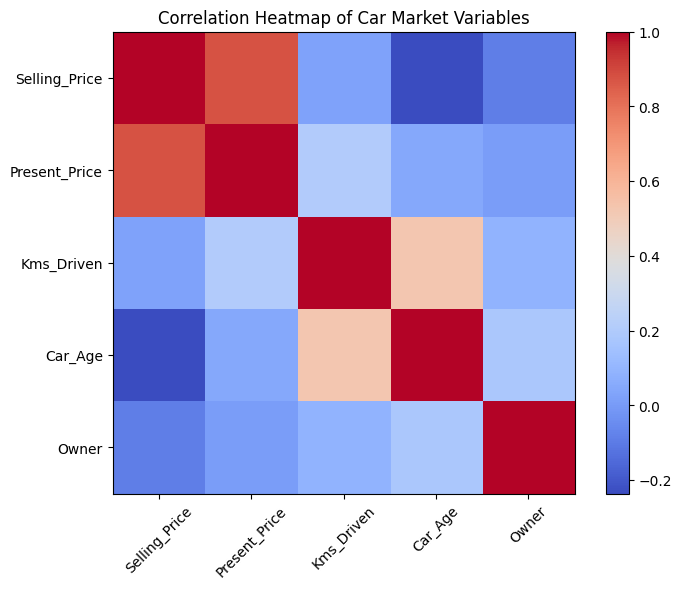

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of Car Market Variables")

plt.show()

### Observation

The correlation heatmap provides a visual representation of the relationships between numerical variables. Colors closer to one end indicate positive relationships, while colors closer to the opposite end indicate negative relationships. This visualization makes it easier to identify variables that have stronger or weaker relationships with each other.

## 13. Key Insights

The following key insights were identified from the Car Market Trends Analysis based on exploratory data analysis, market analysis, price analysis, and correlation analysis.


### 13.1 Market Distribution Insights

- The dataset contains cars with different fuel types, seller types, and transmission types.
- Some categories are more common than others in the dataset.
- The ownership analysis shows the distribution of cars based on the number of previous owners.
- The car model analysis identifies the most frequently occurring car models.


### 13.2 Price Insights

- Car prices vary significantly across the dataset.
- The histogram and box plot help identify the distribution and spread of car prices.
- Some cars may have unusually high or low prices compared with the majority of cars.
- Present price and selling price show an important relationship in the used-car market.


### 13.3 Factors Affecting Selling Price

- Present price is an important factor associated with selling price.
- Car age may influence the resale value of a vehicle.
- Kilometers driven may also affect the selling price.
- Fuel type, transmission type, and seller type can contribute to differences in average selling prices.


### 13.4 Correlation Insights

- Positive correlation indicates that two variables tend to increase together.
- Negative correlation indicates that one variable may decrease as the other increases.
- Variables with correlation values closer to +1 or -1 have stronger relationships.
- The correlation matrix and heatmap help identify important relationships with selling price.

## 14. Conclusion

This Car Market Trends Analysis project was conducted to analyze and understand different patterns and trends in the used car market using Python.

The dataset was analyzed using Pandas and NumPy for data manipulation and numerical analysis. Matplotlib was used to create different visualizations such as bar charts, pie charts, line charts, scatter plots, histograms, box plots, and a correlation heatmap.

The analysis explored different factors including fuel type, seller type, transmission type, ownership, car models, present price, selling price, car age, and kilometers driven.

The results show that different factors can influence the selling price of a car. Present price, car age, kilometers driven, fuel type, transmission type, and ownership can provide useful insights into car market trends.

The correlation analysis helped identify relationships between numerical variables, while data visualizations made it easier to understand patterns, distributions, and trends in the dataset.

Overall, this project demonstrates how data analytics can be used to transform raw car market data into meaningful insights. The analysis can help understand market trends and support better decision-making related to used car pricing and market analysis.